In [32]:
import pandas as pd
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

df = pd.read_csv("Youtube-Spam-Dataset.csv")
print(df.head())

                                    COMMENT_ID            AUTHOR  \
0  LZQPQhLyRh80UYxNuaDWhIGQYNQ96IuCg-AYWqNPjpU         Julius NM   
1  LZQPQhLyRh_C2cTtd9MvFRJedxydaVW-2sNg5Diuo4A       adam riyati   
2  LZQPQhLyRh9MSZYnf8djyk0gEF9BHDPYrrK-qCczIY8  Evgeny Murashkin   
3          z13jhp0bxqncu512g22wvzkasxmvvzjaz04   ElNino Melendez   
4          z13fwbwp1oujthgqj04chlngpvzmtt3r3dw            GsMega   

                  DATE                                            CONTENT  \
0  2013-11-07T06:20:48  Huh, anyway check out this you[tube] channel: ...   
1  2013-11-07T12:37:15  Hey guys check out my new channel and our firs...   
2  2013-11-08T17:34:21             just for test I have to say murdev.com   
3  2013-11-09T08:28:43   me shaking my sexy ass on my channel enjoy ^_^ ﻿   
4  2013-11-10T16:05:38            watch?v=vtaRGgvGtWQ   Check this out .﻿   

                       VIDEO_NAME  CLASS  
0  PSY - GANGNAM STYLE(?????) M/V      1  
1  PSY - GANGNAM STYLE(?????) M/V      1  

In [33]:
df.columns

Index(['COMMENT_ID', 'AUTHOR', 'DATE', 'CONTENT', 'VIDEO_NAME', 'CLASS'], dtype='str')

In [34]:
df.info()
df['CLASS'].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 1956 entries, 0 to 1955
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   COMMENT_ID  1956 non-null   str  
 1   AUTHOR      1956 non-null   str  
 2   DATE        1711 non-null   str  
 3   CONTENT     1956 non-null   str  
 4   VIDEO_NAME  1956 non-null   str  
 5   CLASS       1956 non-null   int64
dtypes: int64(1), str(5)
memory usage: 91.8 KB


CLASS
1    1005
0     951
Name: count, dtype: int64

In [35]:
import string

def clean_text(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text

df['clean_text'] = df['CONTENT'].apply(clean_text)

df[['CONTENT', 'clean_text']].head()

,CONTENT,clean_text
0,"Huh, anyway check out this you[tube] channel: ...",huh anyway check out this youtube channel koby...
1,Hey guys check out my new channel and our firs...,hey guys check out my new channel and our firs...
2,just for test I have to say murdev.com,just for test i have to say murdevcom
3,me shaking my sexy ass on my channel enjoy ^_^ ﻿,me shaking my sexy ass on my channel enjoy ﻿
4,watch?v=vtaRGgvGtWQ Check this out .﻿,watchvvtarggvgtwq check this out ﻿


In [36]:
from sklearn.model_selection import train_test_split

X = df['clean_text']
y = df['CLASS']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [37]:
from sklearn.linear_model import LogisticRegression

tfidf = TfidfVectorizer(max_features=3000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print("TF-IDF training shape:", X_train_tfidf.shape)
print("TF-IDF testing shape:", X_test_tfidf.shape)

model = LogisticRegression()
model.fit(X_train_tfidf, y_train)

print("Model trained successfully")

TF-IDF training shape: (1564, 3000)
TF-IDF testing shape: (392, 3000)
Model trained successfully


In [38]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

Accuracy: 0.8852040816326531
Precision: 0.9193548387096774
Recall: 0.8507462686567164
F1: 0.8837209302325582


In [39]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[176  15]
 [ 30 171]]


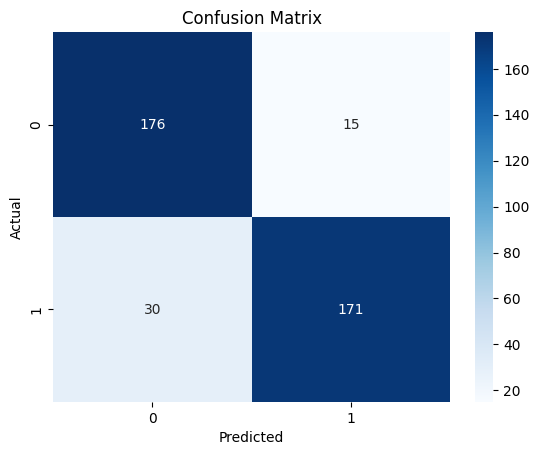

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [41]:
models = {
    "Majority Class Baseline": DummyClassifier(strategy="most_frequent"),
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression()
}

results = []

for name, clf in models.items():
    clf.fit(X_train_tfidf, y_train)
    y_pred_model = clf.predict(X_test_tfidf)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred_model),
        "Precision": precision_score(y_test, y_pred_model, zero_division=0),
        "Recall": recall_score(y_test, y_pred_model, zero_division=0),
        "F1-score": f1_score(y_test, y_pred_model, zero_division=0)
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1-score
0,Majority Class Baseline,0.512755,0.512755,1.000000,0.677909
1,Naive Bayes,0.892857,0.866359,0.935323,0.899522
2,Logistic Regression,0.885204,0.919355,0.850746,0.883721


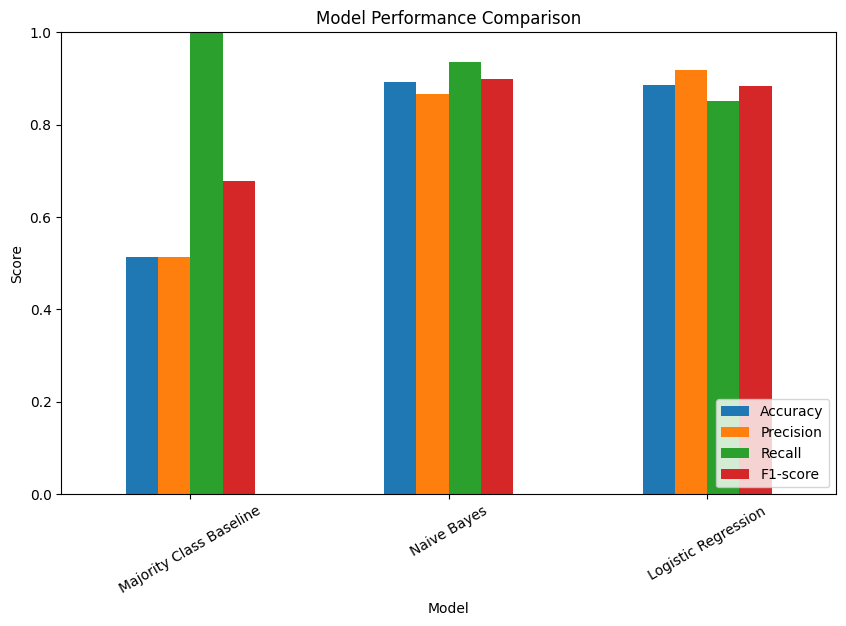

In [42]:
results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-score"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.legend(loc="lower right")
plt.show()

In [43]:
y_probs = model.predict_proba(X_test_tfidf)[:, 1]

thresholds = np.arange(0.1, 0.91, 0.1)
threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_probs >= threshold).astype(int)

    threshold_results.append({
        "Threshold": round(threshold, 2),
        "Precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "Recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "F1-score": f1_score(y_test, y_pred_threshold, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1-score
0,0.1,0.537634,0.995025,0.698080
1,0.2,0.613003,0.985075,0.755725
2,0.3,0.726592,0.965174,0.829060
3,0.4,0.859223,0.880597,0.869779
4,0.5,0.919355,0.850746,0.883721
5,0.6,0.970760,0.825871,0.892473
6,0.7,0.993464,0.756219,0.858757
7,0.8,0.992366,0.646766,0.783133
8,0.9,1.000000,0.412935,0.584507


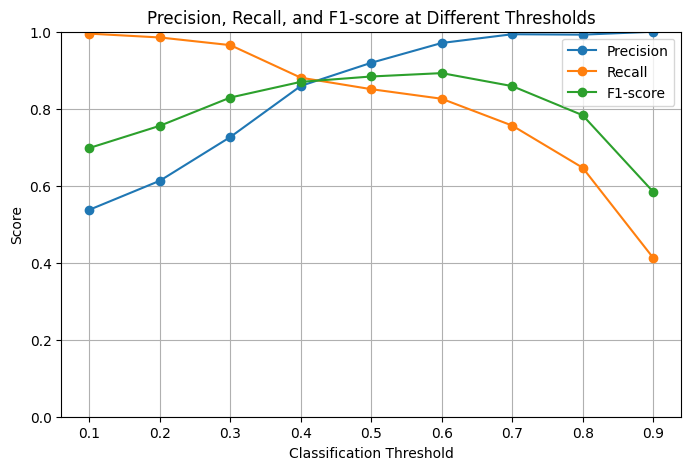

In [44]:
plt.figure(figsize=(8, 5))

plt.plot(threshold_df["Threshold"], threshold_df["Precision"], marker="o", label="Precision")
plt.plot(threshold_df["Threshold"], threshold_df["Recall"], marker="o", label="Recall")
plt.plot(threshold_df["Threshold"], threshold_df["F1-score"], marker="o", label="F1-score")

plt.title("Precision, Recall, and F1-score at Different Thresholds")
plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.show()

In [45]:
feature_names = np.array(tfidf.get_feature_names_out())
coefficients = model.coef_[0]

top_spam_indices = coefficients.argsort()[-20:][::-1]
top_nonspam_indices = coefficients.argsort()[:20]

top_spam_words = pd.DataFrame({
    "Word": feature_names[top_spam_indices],
    "Coefficient": coefficients[top_spam_indices]
})

top_nonspam_words = pd.DataFrame({
    "Word": feature_names[top_nonspam_indices],
    "Coefficient": coefficients[top_nonspam_indices]
})

print("Top words associated with spam:")
display(top_spam_words)

print("Top words associated with non-spam:")
display(top_nonspam_words)

Top words associated with spam:


,Word,Coefficient
0,out,4.412746
1,check,4.049516
2,subscribe,3.847010
3,please,3.061828
4,my,2.552112
5,channel,2.286060
6,if,2.118798
7,on,1.992117
8,for,1.940736
9,comment,1.854295


Top words associated with non-spam:


,Word,Coefficient
0,song,-2.988250
1,views,-2.779190
2,love,-2.515355
3,is,-2.250112
4,billion,-1.724563
5,shakira,-1.716162
6,best,-1.593333
7,good,-1.425261
8,years,-1.277317
9,perry,-1.228480


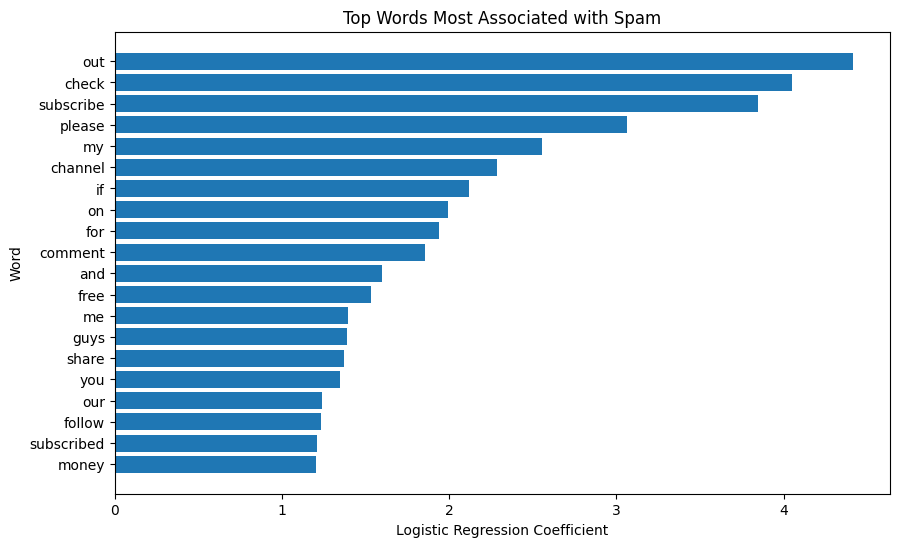

In [46]:
plt.figure(figsize=(10, 6))

plt.barh(top_spam_words["Word"], top_spam_words["Coefficient"])

plt.title("Top Words Most Associated with Spam")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Word")
plt.gca().invert_yaxis()
plt.show()

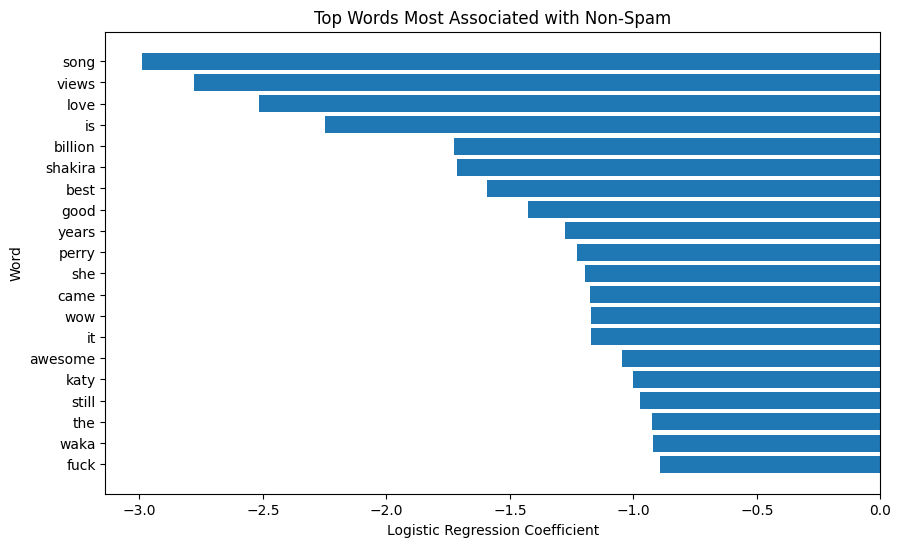

In [47]:
plt.figure(figsize=(10, 6))

plt.barh(top_nonspam_words["Word"], top_nonspam_words["Coefficient"])

plt.title("Top Words Most Associated with Non-Spam")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Word")
plt.gca().invert_yaxis()
plt.show()

In [48]:
error_df = pd.DataFrame({
    "Comment": X_test,
    "Actual": y_test,
    "Predicted": y_pred,
    "Spam Probability": y_probs
})

false_positives = error_df[
    (error_df["Actual"] == 0) & 
    (error_df["Predicted"] == 1)
]

false_negatives = error_df[
    (error_df["Actual"] == 1) & 
    (error_df["Predicted"] == 0)
]

print("Number of false positives:", len(false_positives))
print("Number of false negatives:", len(false_negatives))

Number of false positives: 15
Number of false negatives: 30


In [49]:
print("False positives: normal comments predicted as spam")
display(false_positives.head(10))

print("False negatives: spam comments predicted as normal")
display(false_negatives.head(10))

False positives: normal comments predicted as spam


,Comment,Actual,Predicted,Spam Probability
679,hii youtube﻿,0,1,0.601553
459,this comment will randomly get lots of likes a...,0,1,0.820701
1484,thumbs up if you listen this in 2015﻿,0,1,0.658200
1191,we go for 1000000000 for eminem﻿,0,1,0.615290
229,we pray for you little psy ♡﻿,0,1,0.607984
264,if you pause at 139 at the last millisecond yo...,0,1,0.590595
417,in my opinion i think you look better with bla...,0,1,0.534744
1489,hi i am from bangladesh 💜﻿,0,1,0.533202
1158,this song is about rape and cheating br br...,0,1,0.530422
871,thumbs up if you39re watching in 2015﻿,0,1,0.587828


False negatives: spam comments predicted as normal


,Comment,Actual,Predicted,Spam Probability
173,httpwwwgofundmecomgvr7xg﻿,1,0,0.391973
400,hid we’ re twin melody 17 year old twins we...,1,0,0.498069
545,nice song see my new track﻿,1,0,0.434965
1667,definitley the song for 2010 when im not liste...,1,0,0.267028
47,httpwwwavaazorgpopetitionyoutubecorporationfox...,1,0,0.391973
268,httpswwwfacebookcompagesmathsterwp149532392074...,1,0,0.391973
353,httppsnbosscomref2tggp3pv6l this is the song﻿,1,0,0.019098
522,j aiiima plzzz httpswwwfacebookcompagesc389cc...,1,0,0.391973
913,iiiiiiiiiii love this shake it song oh sorry e...,1,0,0.218741
1223,wow justin bieber is better thats why when he...,1,0,0.338620
